In [ ]:
import json
import os.path
import re
import yaml
import pandas as pd
import matplotlib.pyplot as plt

CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def load_query_text(query_file):
    with open(query_file) as f:
        return yaml.safe_load(f)["query"]

def get_file_size(suite_name):
    if "json" in suite_name.lower():
        return JSON_PERSON_FILE_SIZE
    return CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name, query_dir):
    with open(filepath) as f:
        data = json.load(f)
    file_size = get_file_size(suite_name)
    rows = []
    for r in data:
        if r.get("state") != "Stopped":
            continue
        exec_time = (r["stop_time_ms"] - r["start_time_ms"]) / 1000.0
        if exec_time <= 0:
            continue
        query_file = os.path.join(query_dir, os.path.basename(r["query_file"]))
        query_text = shorten_query(load_query_text(query_file))
        rows.append({
            "suite": suite_name,
            "query": query_text,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776374217.json", "CSV baseline", "queries-evaluated")
rows += load_suite("results/optimized_results_1776375022.json", "CSV optimized", "queries-evaluated")
rows += load_suite("results/baseline-json_results_1776489253.json", "JSON baseline", "queries-json-evaluated")
rows += load_suite("results/optimized-json_results_1776490691.json", "JSON optimized", "queries-json-evaluated")

rows += load_suite("results/baseline_results_1776507542.json", "CSV baseline", "queries-evaluated")
rows += load_suite("results/optimized_results_1776507806.json", "CSV optimized", "queries-evaluated")
rows += load_suite("results/baseline-json_results_1776512610.json", "JSON baseline", "queries-json-evaluated")
rows += load_suite("results/optimized-json_results_1776513095.json", "JSON optimized", "queries-json-evaluated")

df = pd.DataFrame(rows)
df = df[df["threads"] != 48].reset_index(drop=True)
print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {sorted(df['threads'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
df

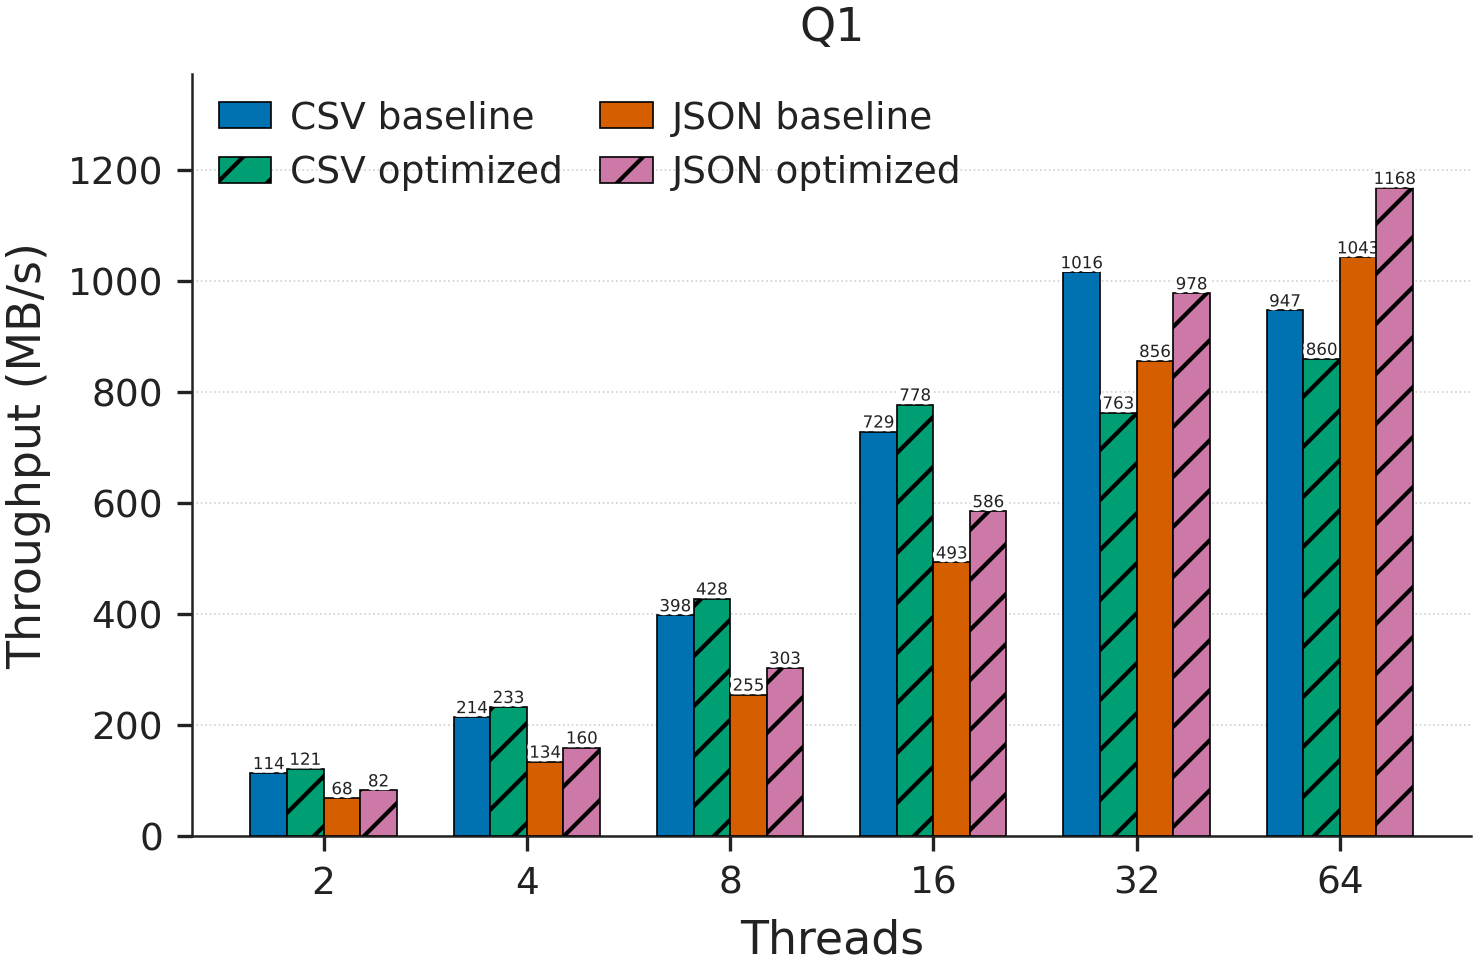

wrote plots/varsized_copy_throughput_q2.pdf


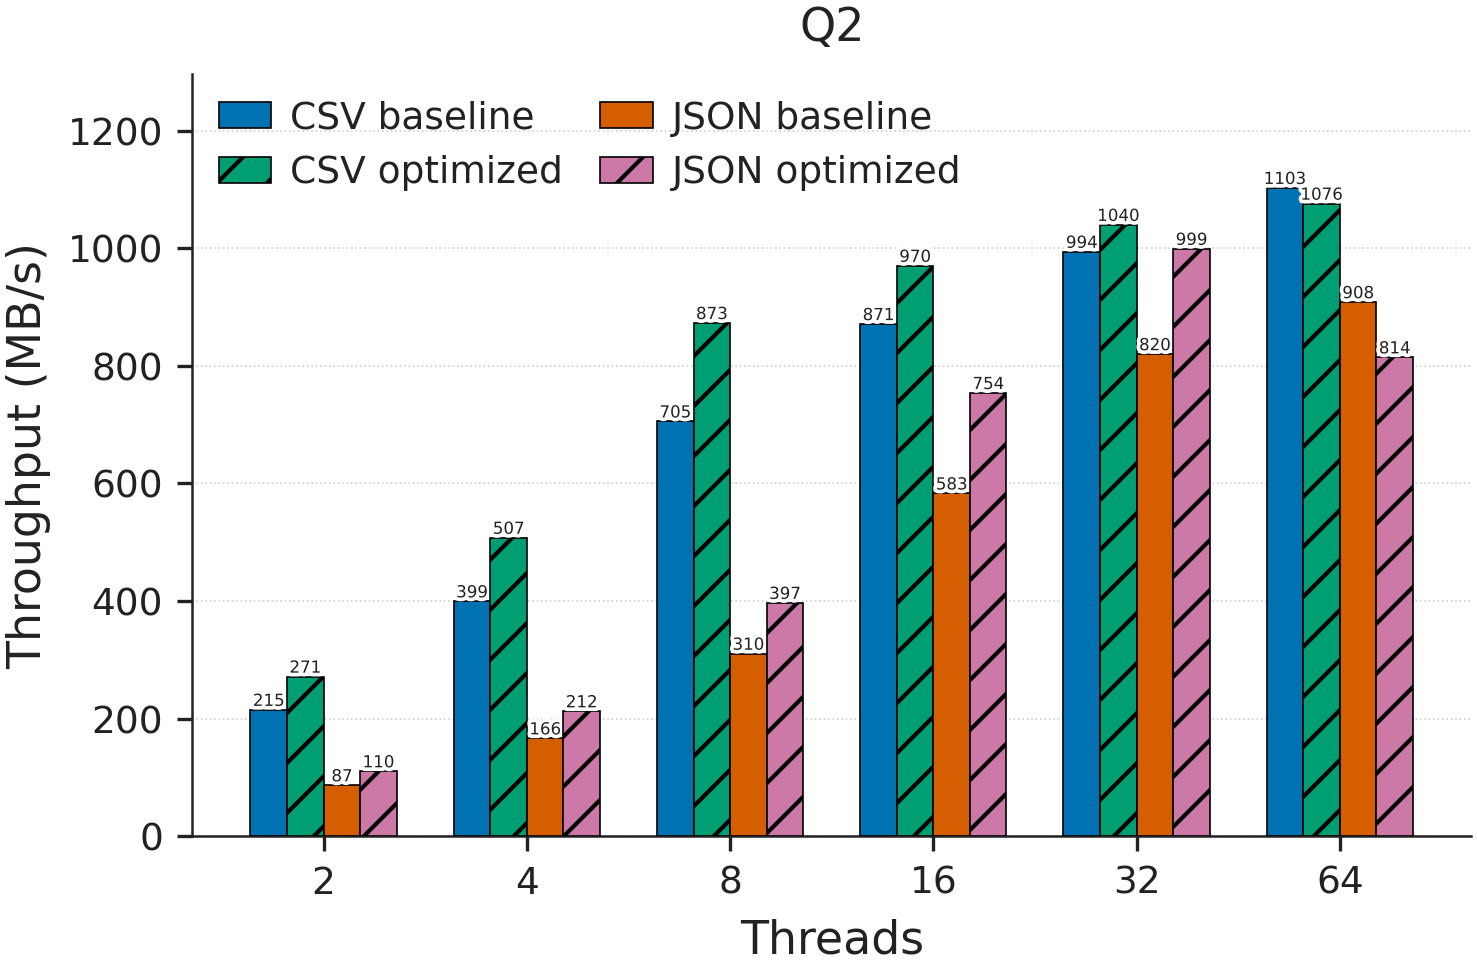

wrote plots/varsized_copy_throughput_q3.pdf


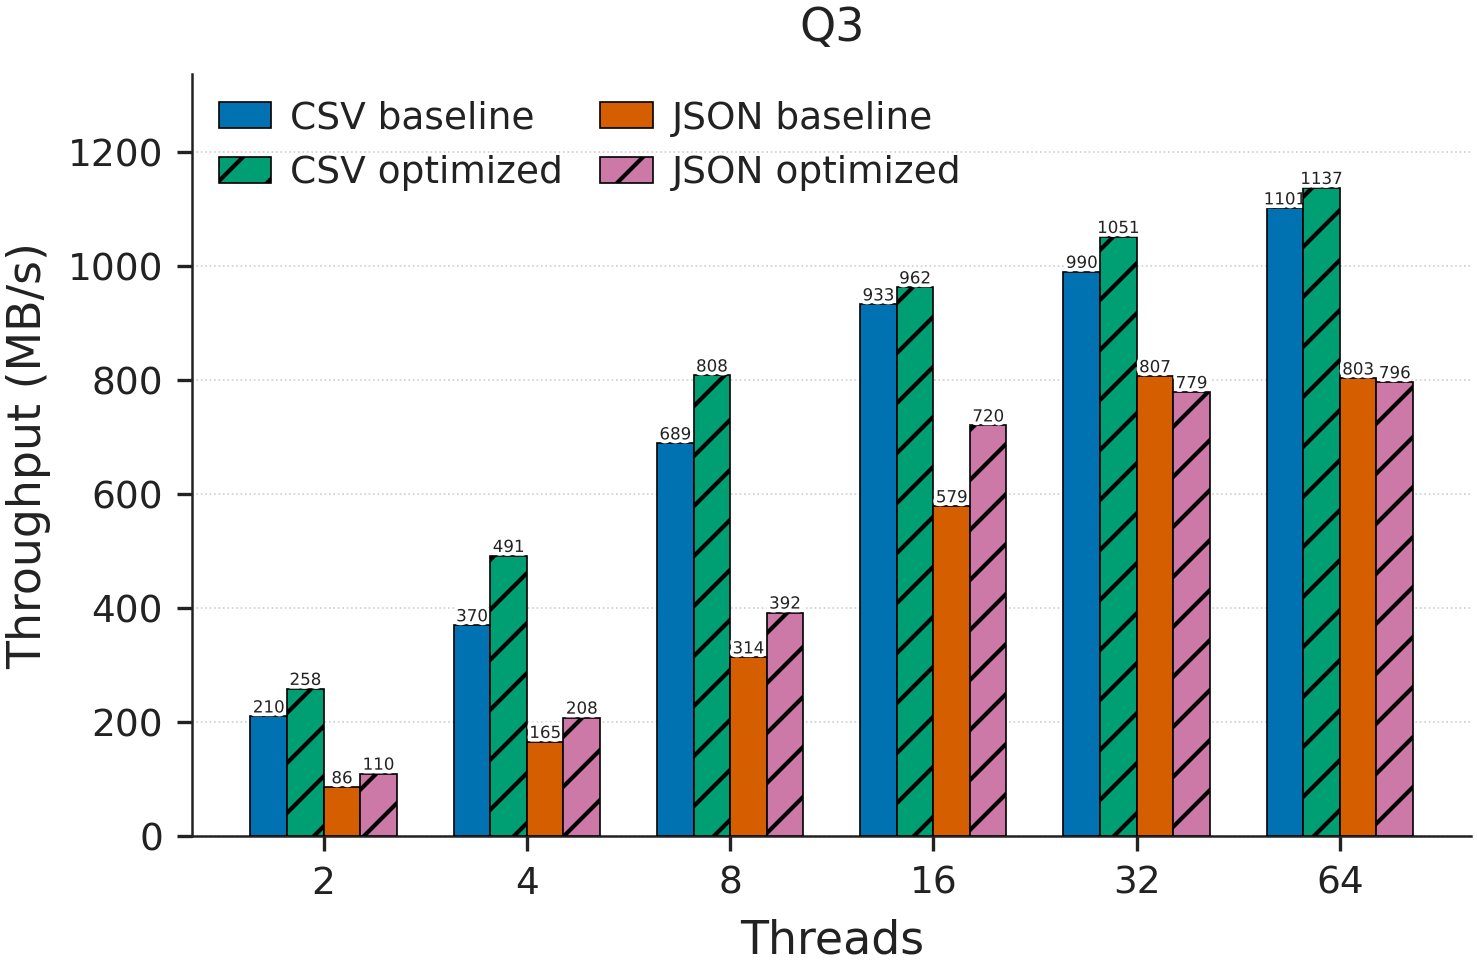

wrote plots/varsized_copy_throughput_q4.pdf


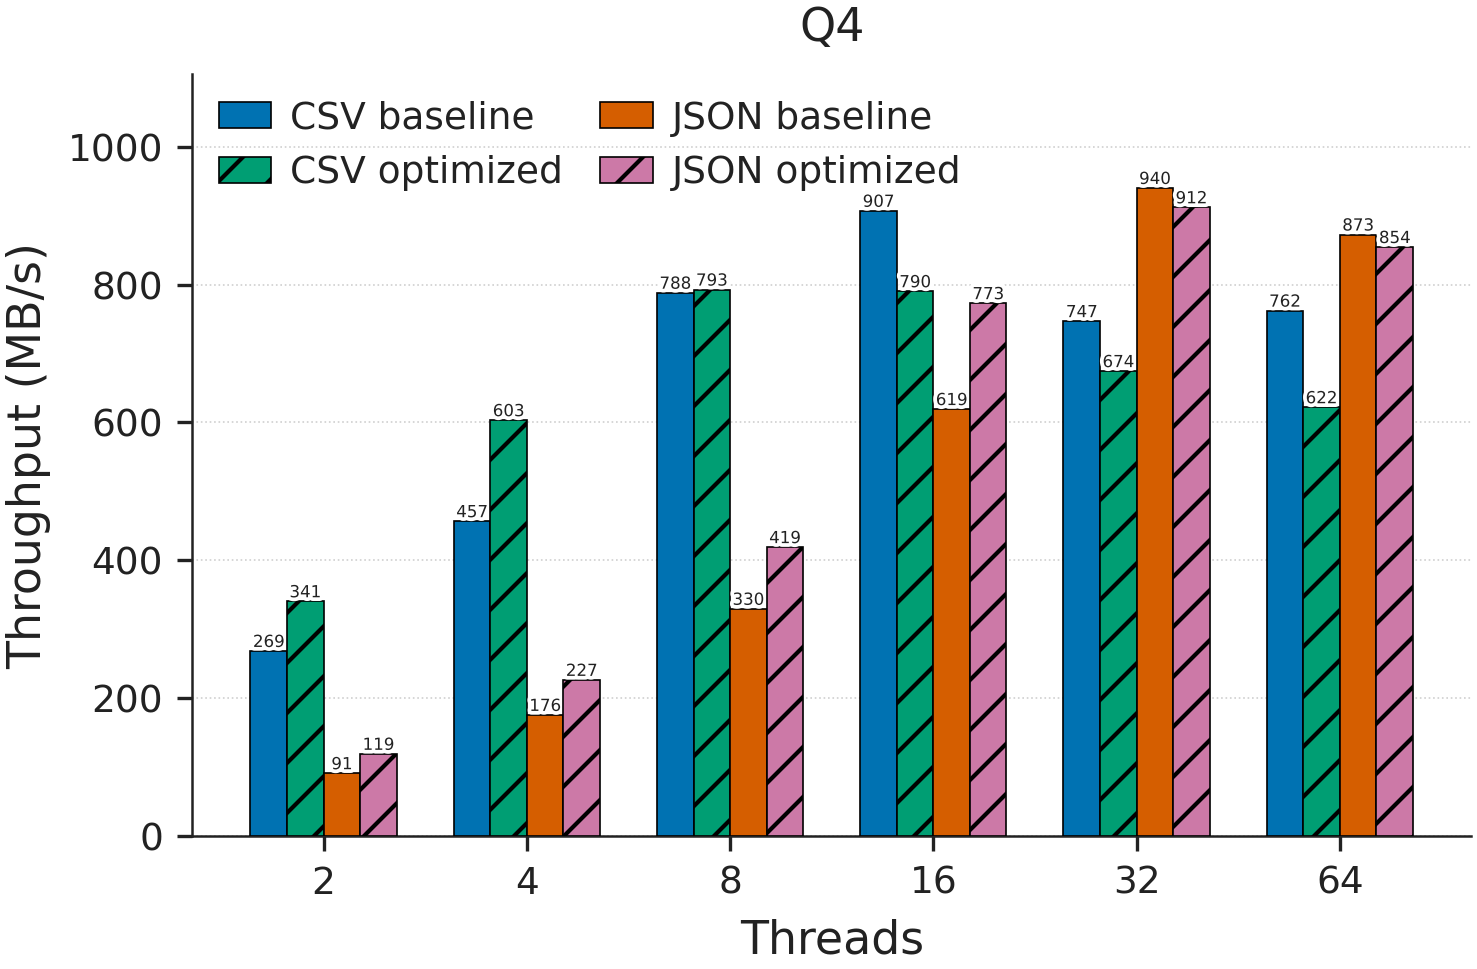

In [61]:
# Grouped bar chart: suites per thread count, one standalone plot per query
import os
import re
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline": "#0072B2",
    "CSV optimized": "#009E73",
    "JSON baseline": "#D55E00",
    "JSON optimized": "#CC79A7",
}
suite_hatch = {
    "CSV baseline": "",
    "CSV optimized": "//",
    "JSON baseline": "",
    "JSON optimized": "//",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

query_file_labels = {
    q: re.sub(r"[^a-z0-9]+", "_", query_labels[q].lower()).strip("_") for q in queries
}

with mpl.rc_context(thesis_rc):
    for q in queries:
        fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

        for j, suite in enumerate(suites):
            s_data = df[(df["query"] == q) & (df["suite"] == suite)]
            vals = s_data.groupby("threads")["throughput_MBs"].median().reindex(thread_counts)
            offset = (j - (n_suites - 1) / 2) * bar_width
            bars = ax.bar(
                x + offset,
                vals.values,
                bar_width,
                label=suite,
                color=suite_colors[suite],
                edgecolor="black",
                linewidth=0.4,
                hatch=suite_hatch[suite],
                zorder=3,
            )
            for bar in bars:
                h = bar.get_height()
                if h is not None and not np.isnan(h):
                    txt = ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h,
                        f"{h:.0f}",
                        ha="center",
                        va="bottom",
                        fontsize=4,
                        color="#222222",
                    )
                    txt.set_path_effects([pe.withStroke(linewidth=1.8, foreground="white")])

        ax.set_xlabel("Threads")
        ax.set_ylabel("Throughput (MB/s)")
        ax.set_title(query_labels[q], pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels(thread_counts)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            loc="upper left",
            ncol=2,
            columnspacing=1.0,
            handlelength=1.4,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        out = os.path.join(
            PLOTS_DIR,
            f"varsized_copy_throughput_{query_file_labels[q]}.pdf",
        )
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()

wrote plots/varsized_copy_exec_time_q1.pdf


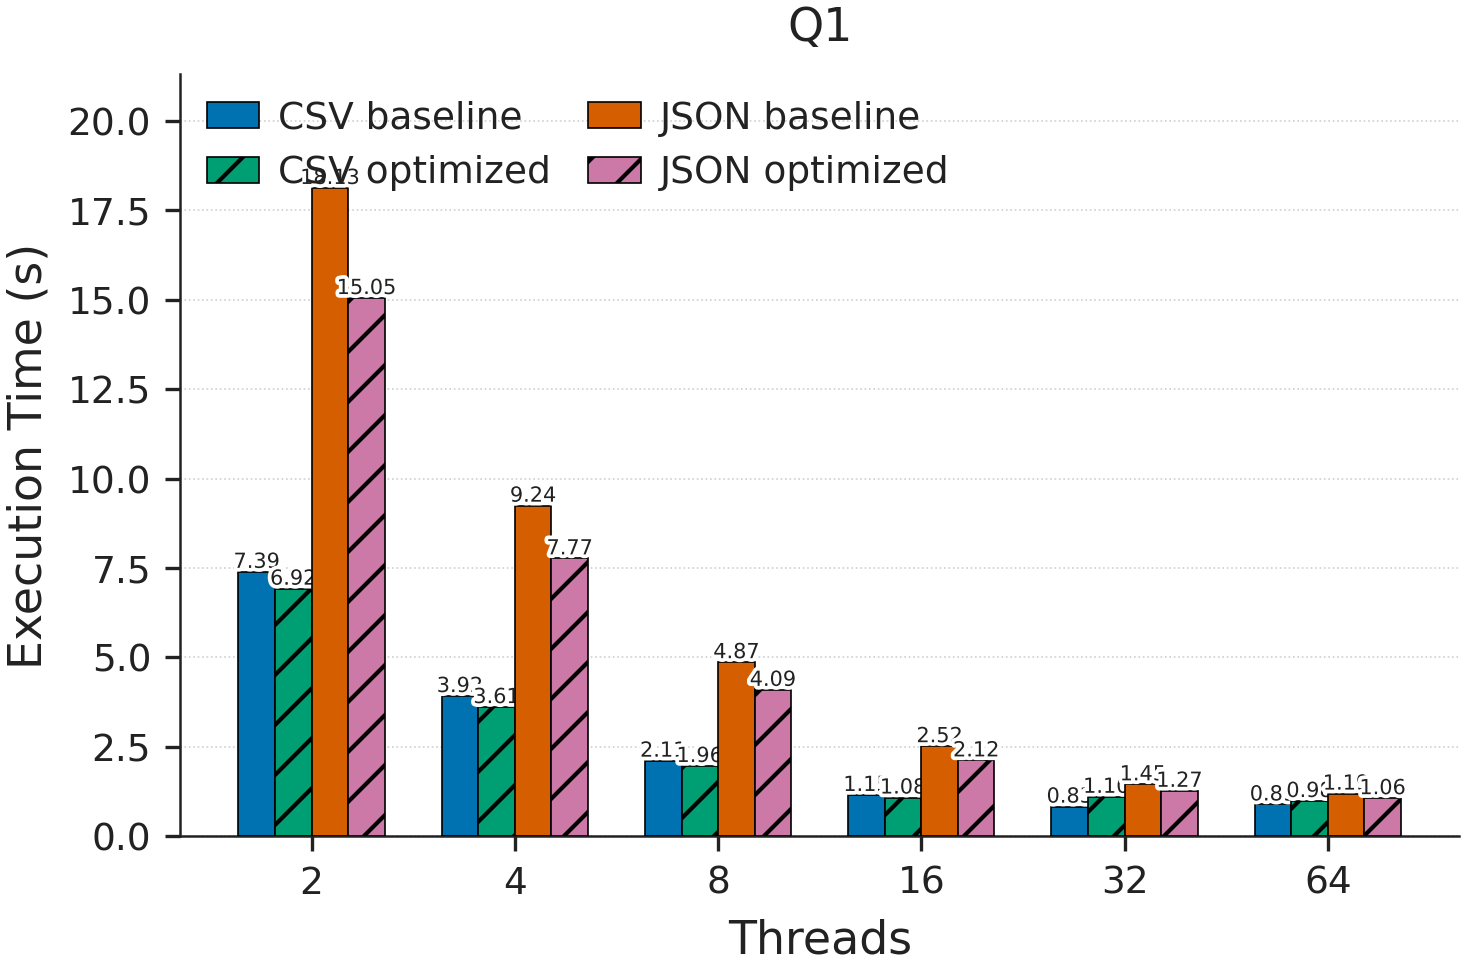

wrote plots/varsized_copy_exec_time_q2.pdf


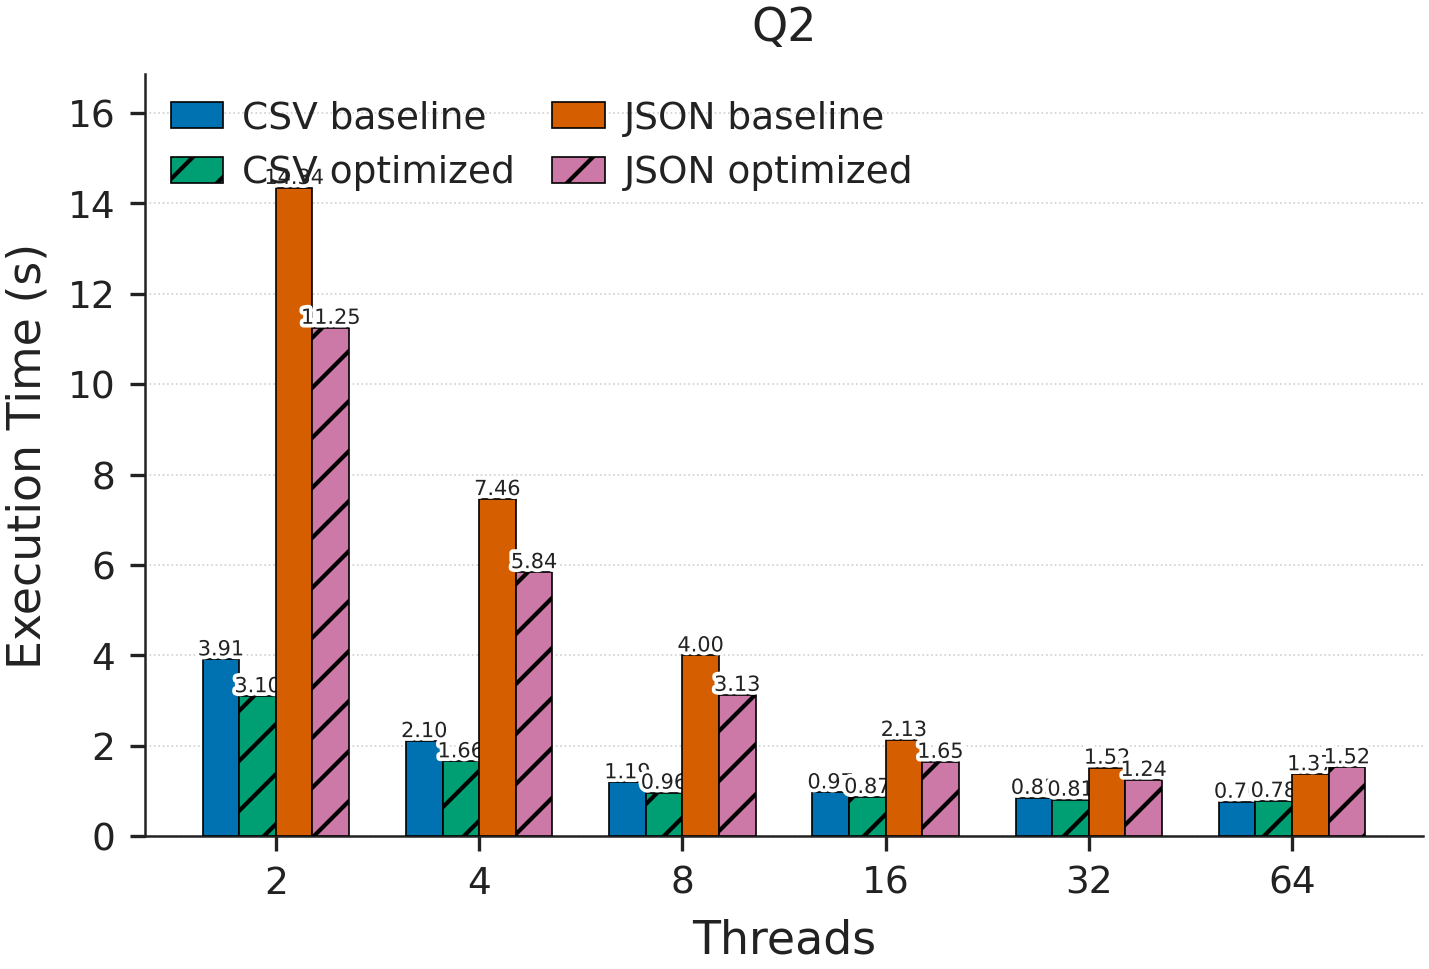

wrote plots/varsized_copy_exec_time_q3.pdf


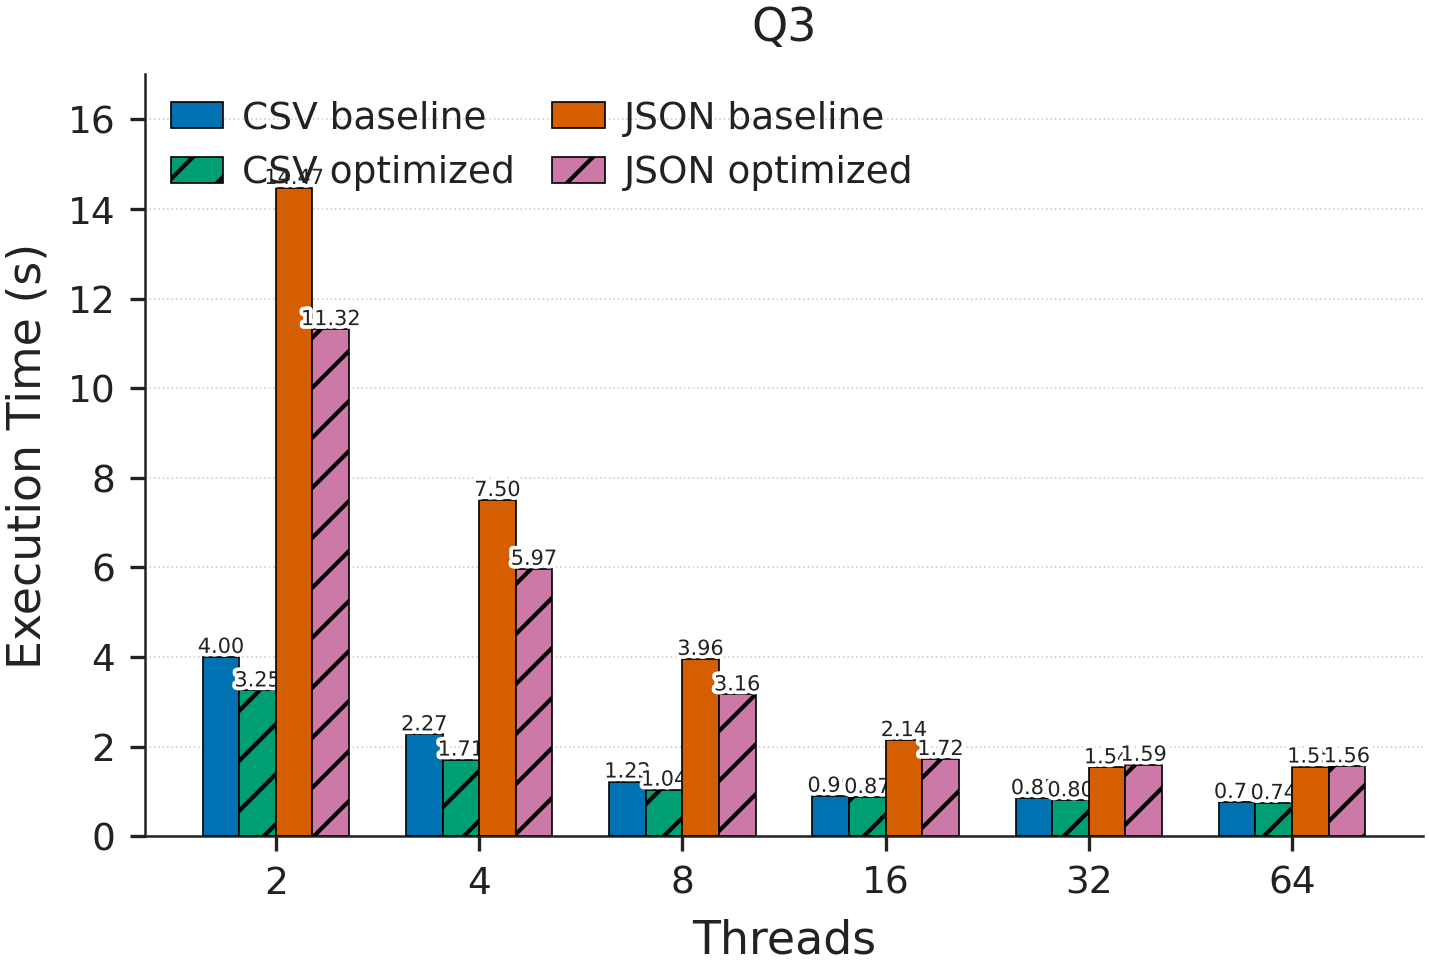

wrote plots/varsized_copy_exec_time_q4.pdf


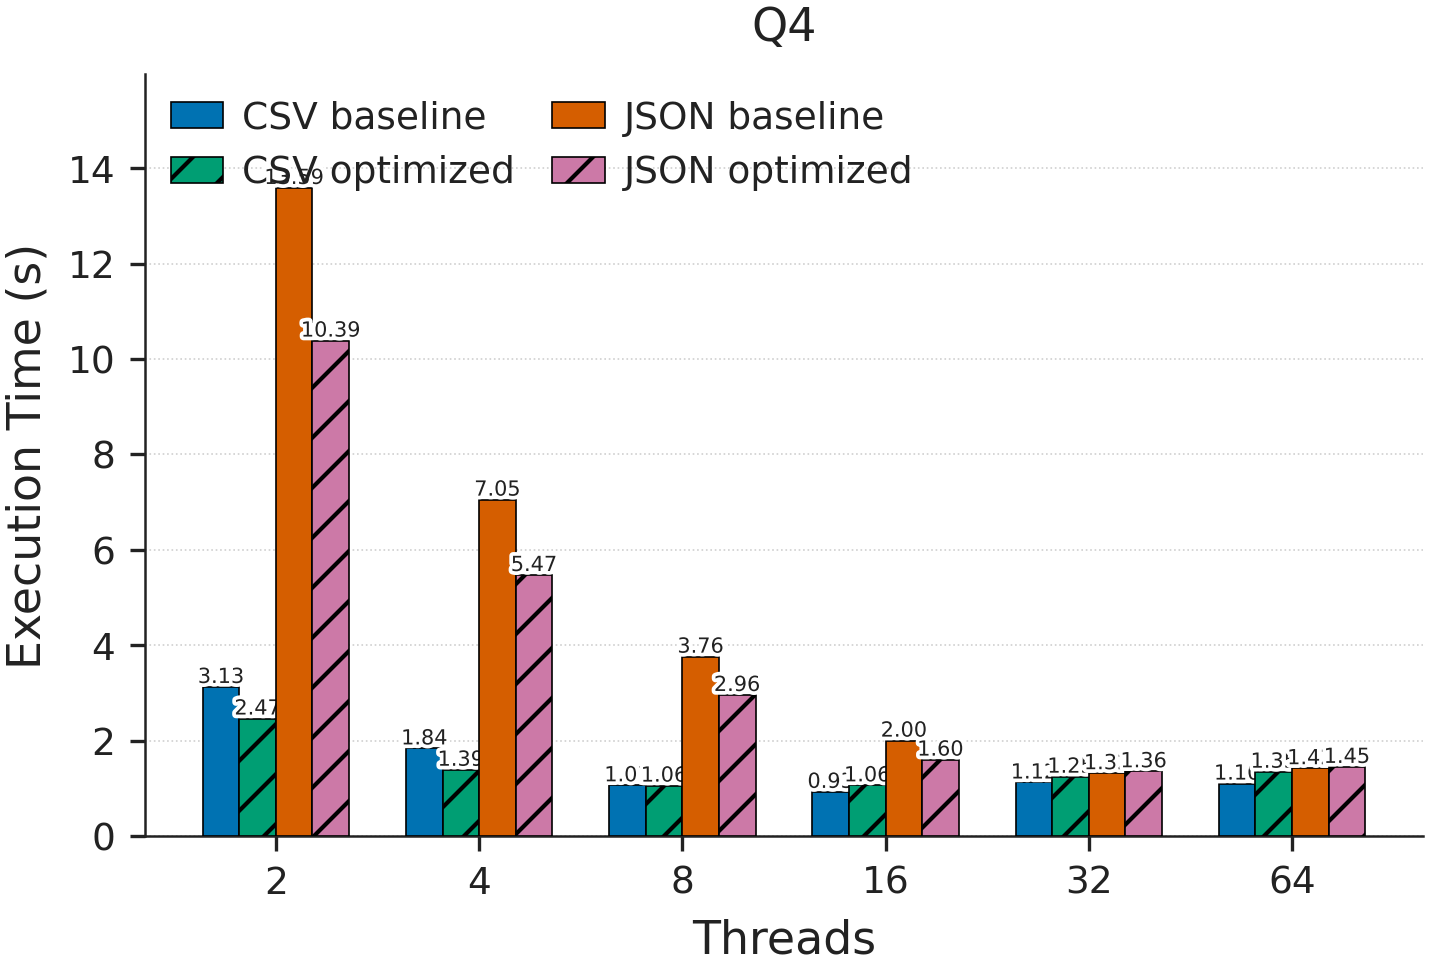

In [62]:
# Grouped bar chart: execution time per thread count, one standalone plot per query
import os
import re
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline": "#0072B2",
    "CSV optimized": "#009E73",
    "JSON baseline": "#D55E00",
    "JSON optimized": "#CC79A7",
}
suite_hatch = {
    "CSV baseline": "",
    "CSV optimized": "//",
    "JSON baseline": "",
    "JSON optimized": "//",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

query_file_labels = {
    q: re.sub(r"[^a-z0-9]+", "_", query_labels[q].lower()).strip("_") for q in queries
}

with mpl.rc_context(thesis_rc):
    for q in queries:
        fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

        for j, suite in enumerate(suites):
            s_data = df[(df["query"] == q) & (df["suite"] == suite)]
            vals = s_data.groupby("threads")["exec_time_s"].median().reindex(thread_counts)
            offset = (j - (n_suites - 1) / 2) * bar_width
            bars = ax.bar(
                x + offset,
                vals.values,
                bar_width,
                label=suite,
                color=suite_colors[suite],
                edgecolor="black",
                linewidth=0.4,
                hatch=suite_hatch[suite],
                zorder=3,
            )
            for bar in bars:
                h = bar.get_height()
                if h is not None and not np.isnan(h):
                    txt = ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h,
                        f"{h:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=5,
                        color="#222222",
                    )
                    txt.set_path_effects([pe.withStroke(linewidth=1.8, foreground="white")])

        ax.set_xlabel("Threads")
        ax.set_ylabel("Execution Time (s)")
        ax.set_title(query_labels[q], pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels(thread_counts)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            loc="upper left",
            ncol=2,
            columnspacing=1.0,
            handlelength=1.4,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        out = os.path.join(
            PLOTS_DIR,
            f"varsized_copy_exec_time_{query_file_labels[q]}.pdf",
        )
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()

wrote plots/varsized_copy_throughput_median.pdf


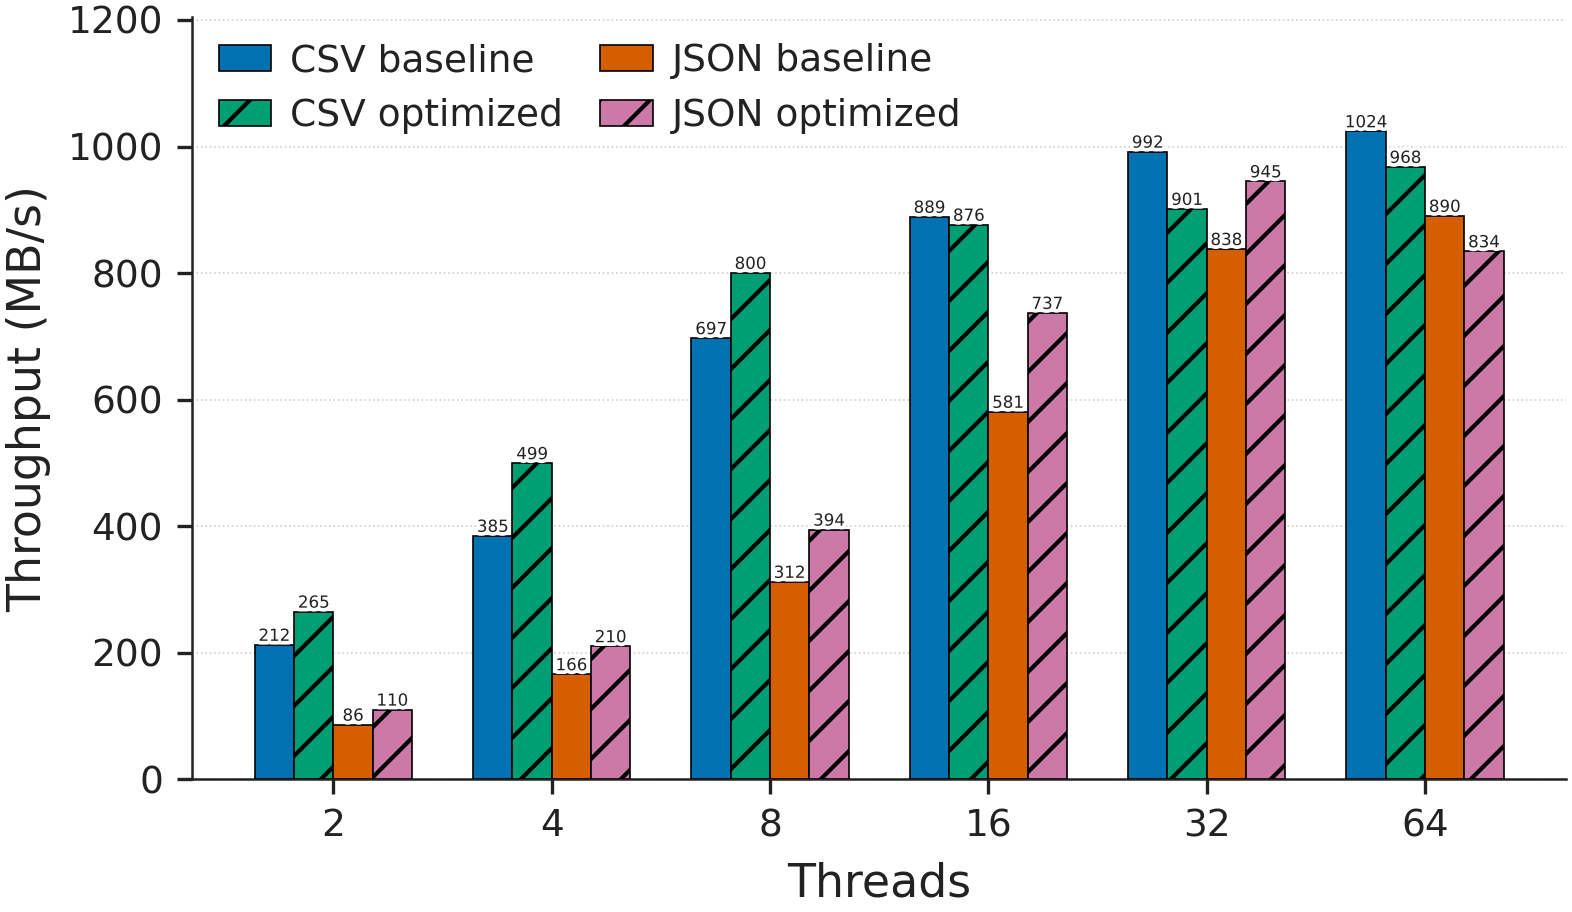

In [63]:
# Median throughput across all queries per suite & thread count
import os
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#0072B2",
    "CSV optimized": "#009E73",
    "JSON baseline": "#D55E00",
    "JSON optimized": "#CC79A7",
}
suite_hatch = {
    "CSV baseline":  "",
    "CSV optimized": "//",
    "JSON baseline": "",
    "JSON optimized": "//",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

median_across = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

    for j, suite in enumerate(suites):
        if suite not in median_across.index.get_level_values("suite"):
            continue
        vals = median_across.loc[suite].reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset,
            vals.values,
            bar_width,
            label=suite,
            color=suite_colors[suite],
            edgecolor="black",
            linewidth=0.4,
            hatch=suite_hatch[suite],
            zorder=3,
        )
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h,
                    f"{h:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=4,
                    color="#222222",
                )
                txt.set_path_effects([pe.withStroke(linewidth=1.8, foreground="white")])

    ax.set_xlabel("Threads")
    ax.set_ylabel("Throughput (MB/s)")
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper left",
        ncol=2,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    fig.tight_layout()
    out = os.path.join(PLOTS_DIR, "varsized_copy_throughput_median.pdf")
    fig.savefig(out)
    print(f"wrote {out}")
    plt.show()

wrote plots/varsized_copy_throughput_variance.pdf


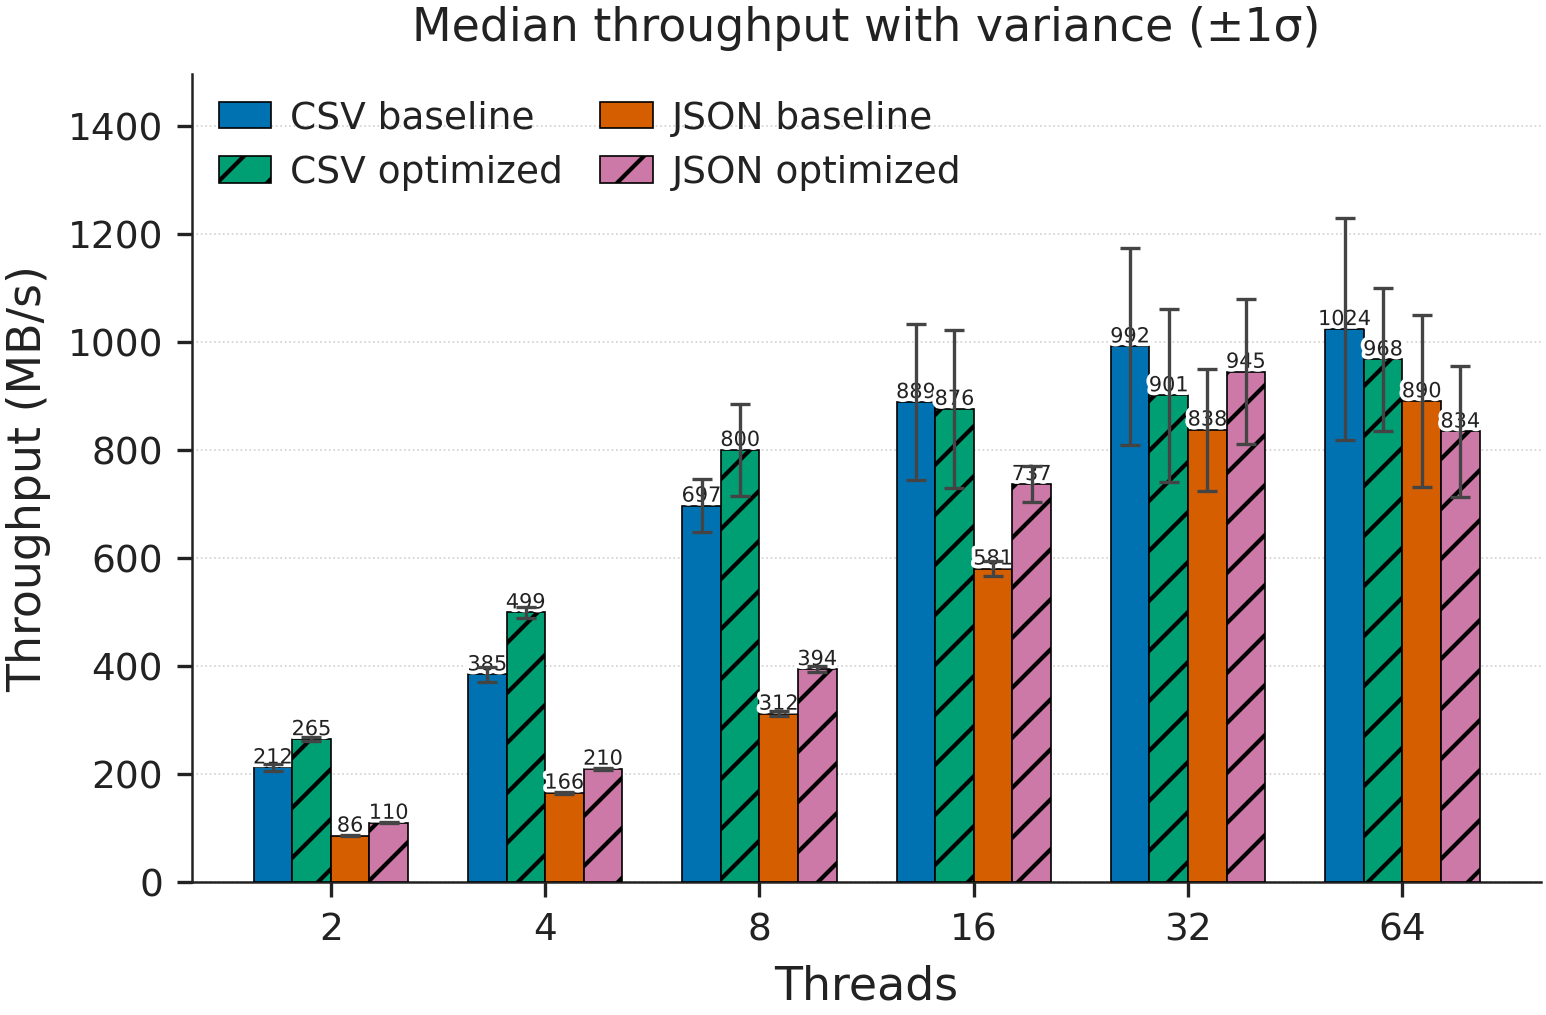

In [68]:
# Throughput variability across repeated executions per suite & thread count
import os
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline": "#0072B2",
    "CSV optimized": "#009E73",
    "JSON baseline": "#D55E00",
    "JSON optimized": "#CC79A7",
}
suite_hatch = {
    "CSV baseline": "",
    "CSV optimized": "//",
    "JSON baseline": "",
    "JSON optimized": "//",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

per_query_stats = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .agg(center="median", spread=lambda s: s.std(ddof=1))
    .fillna(0.0)
)

variance_summary = (
    per_query_stats.groupby(level=["suite", "threads"])
    .agg(center=("center", "median"), spread=("spread", "median"))
)

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(5.8, 3.5), dpi=300)

    for j, suite in enumerate(suites):
        if suite not in variance_summary.index.get_level_values("suite"):
            continue
        center = variance_summary.loc[suite]["center"].reindex(thread_counts)
        spread = variance_summary.loc[suite]["spread"].reindex(thread_counts).fillna(0.0)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset,
            center.values,
            bar_width,
            label=suite,
            color=suite_colors[suite],
            edgecolor="black",
            linewidth=0.4,
            hatch=suite_hatch[suite],
            yerr=spread.values,
            error_kw={"elinewidth": 0.8, "ecolor": "#444444", "capsize": 2.5, "capthick": 0.8},
            zorder=3,
        )
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h,
                    f"{h:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=5,
                    color="#222222",
                )
                txt.set_path_effects([pe.withStroke(linewidth=1.8, foreground="white")])

    ax.set_xlabel("Threads")
    ax.set_ylabel("Throughput (MB/s)")
    ax.set_title("Median throughput with variance (±1σ)", pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.16)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper left",
        ncol=2,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    out = os.path.join(PLOTS_DIR, "varsized_copy_throughput_variance.pdf")
    fig.savefig(out)
    print(f"wrote {out}")
    plt.show()

wrote plots/varsized_copy_speedup.pdf


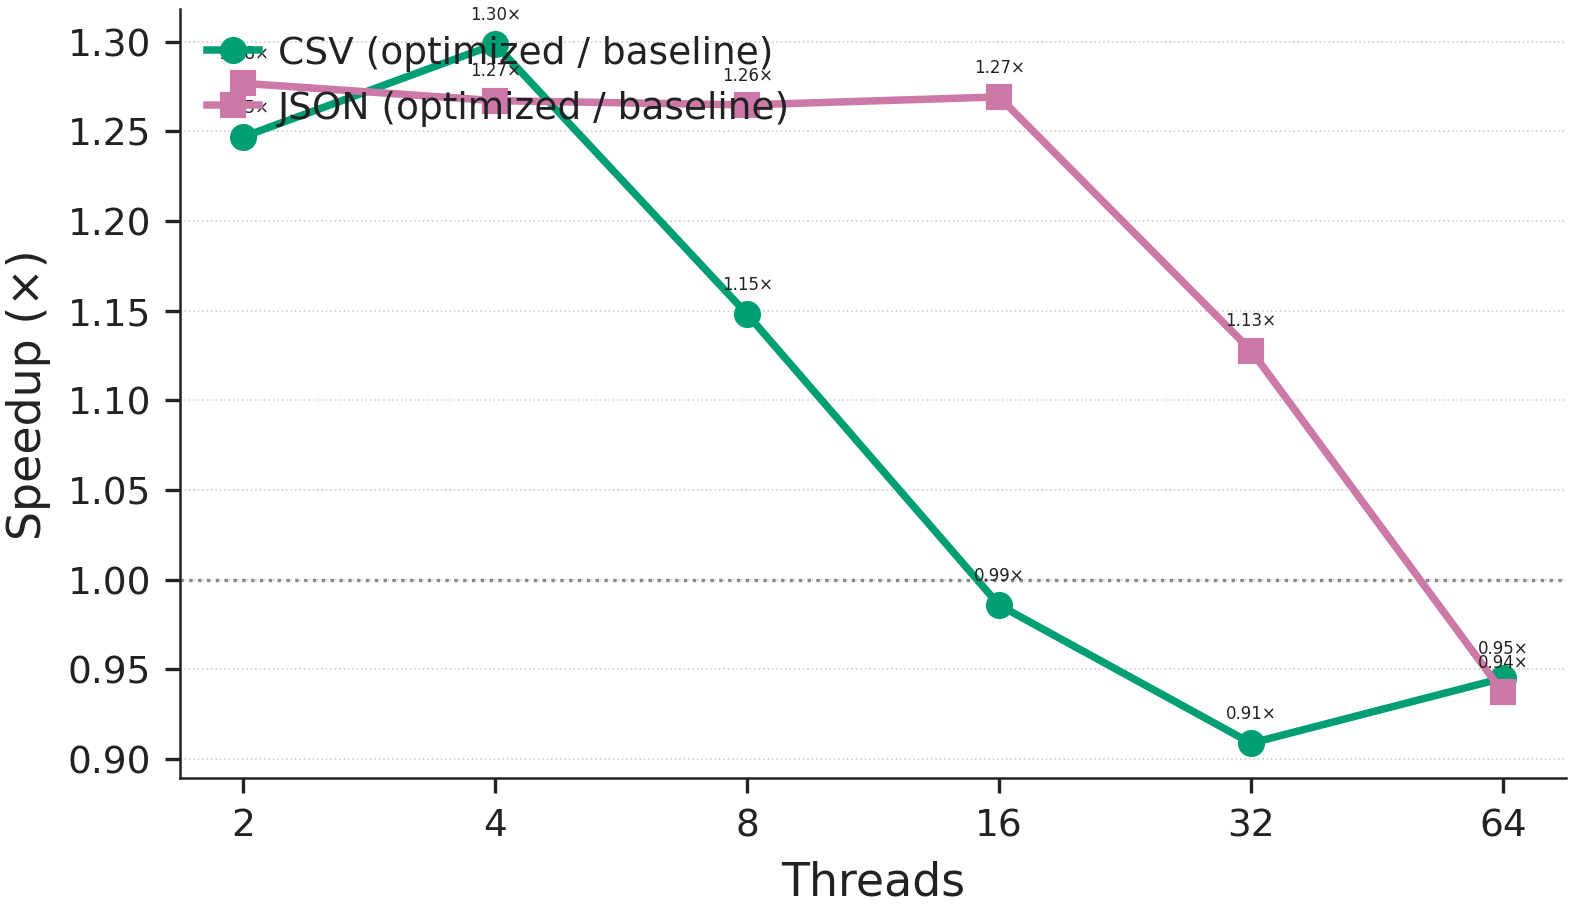

,CSV,JSON
2,1.247,1.277
4,1.298,1.267
8,1.148,1.265
16,0.986,1.269
32,0.909,1.128
64,0.945,0.937


In [69]:
# Speedup curves: optimized / baseline throughput vs threads
import os
import numpy as np
import matplotlib as mpl

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

thread_counts = sorted(df["threads"].unique())

median_tp = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
    .unstack("threads")
    .reindex(columns=thread_counts)
)

speedup = pd.DataFrame(index=thread_counts)
if {"CSV baseline", "CSV optimized"}.issubset(median_tp.index):
    speedup["CSV"] = (median_tp.loc["CSV optimized"] / median_tp.loc["CSV baseline"]).values
if {"JSON baseline", "JSON optimized"}.issubset(median_tp.index):
    speedup["JSON"] = (median_tp.loc["JSON optimized"] / median_tp.loc["JSON baseline"]).values

fmt_colors = {"CSV": "#009E73", "JSON": "#CC79A7"}
fmt_markers = {"CSV": "o", "JSON": "s"}

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

    for fmt in speedup.columns:
        ax.plot(
            thread_counts,
            speedup[fmt].values,
            marker=fmt_markers[fmt],
            markersize=5.5,
            linewidth=1.8,
            color=fmt_colors[fmt],
            label=f"{fmt} (optimized / baseline)",
        )
        for x_val, y_val in zip(thread_counts, speedup[fmt].values):
            if not np.isnan(y_val):
                ax.annotate(
                    f"{y_val:.2f}×",
                    xy=(x_val, y_val),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha="center",
                    fontsize=4,
                    color="#222222",
                )

    ax.axhline(1.0, color="#888888", linestyle=":", linewidth=0.8, zorder=1)
    ax.set_xlabel("Threads")
    ax.set_ylabel("Speedup (×)")
    ax.set_xscale("log", base=2)
    ax.set_xticks(thread_counts)
    ax.set_xticklabels(thread_counts)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper left",
        ncol=1,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    fig.tight_layout()
    out = os.path.join(PLOTS_DIR, "varsized_copy_speedup.pdf")
    fig.savefig(out)
    print(f"wrote {out}")
    plt.show()

speedup.round(3)

wrote plots/varsized_copy_exec_time_median.pdf


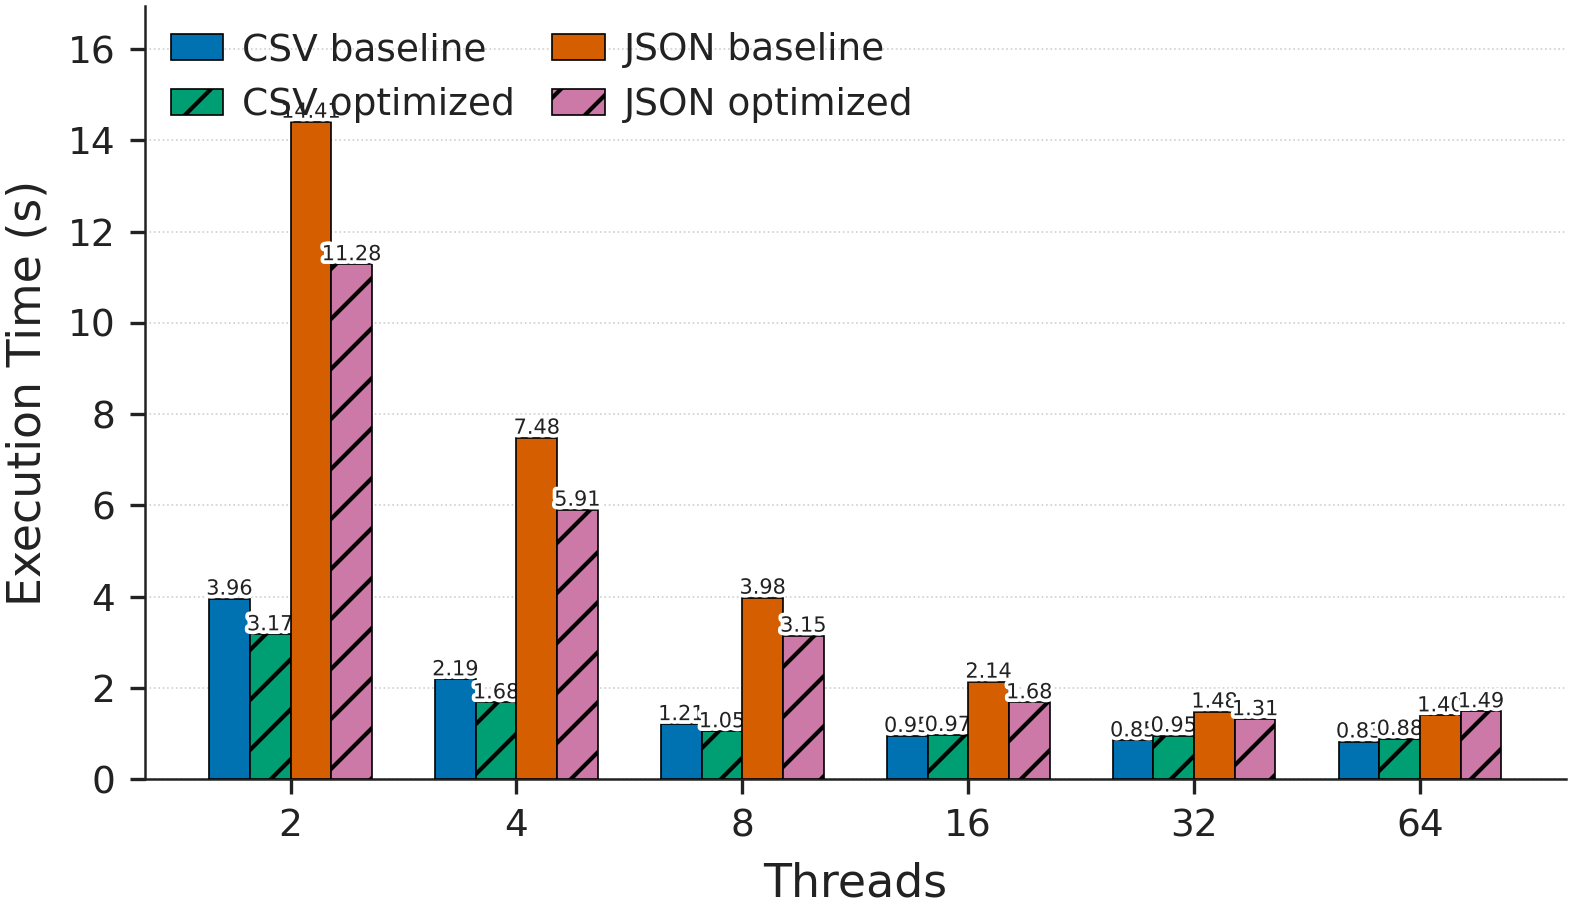

In [70]:
# Median execution time across all queries per suite & thread count
import os
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#0072B2",
    "CSV optimized": "#009E73",
    "JSON baseline": "#D55E00",
    "JSON optimized": "#CC79A7",
}
suite_hatch = {
    "CSV baseline":  "",
    "CSV optimized": "//",
    "JSON baseline": "",
    "JSON optimized": "//",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

median_across = (
    df.groupby(["suite", "threads", "query"])["exec_time_s"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

    for j, suite in enumerate(suites):
        if suite not in median_across.index.get_level_values("suite"):
            continue
        vals = median_across.loc[suite].reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset,
            vals.values,
            bar_width,
            label=suite,
            color=suite_colors[suite],
            edgecolor="black",
            linewidth=0.4,
            hatch=suite_hatch[suite],
            zorder=3,
        )
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h,
                    f"{h:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=5,
                    color="#222222",
                )
                txt.set_path_effects([pe.withStroke(linewidth=1.8, foreground="white")])

    ax.set_xlabel("Threads")
    ax.set_ylabel("Execution Time (s)")
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper left",
        ncol=2,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    fig.tight_layout()
    out = os.path.join(PLOTS_DIR, "varsized_copy_exec_time_median.pdf")
    fig.savefig(out)
    print(f"wrote {out}")
    plt.show()

In [66]:
# Summary table: throughput (MB/s) all 4 suites
all_suites = [s for s in ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"] if s in df["suite"].unique()]
pivot = df.pivot_table(index=["query", "threads"], columns="suite", values="throughput_MBs", aggfunc="median")
pivot = pivot[[s for s in all_suites if s in pivot.columns]]
if "CSV baseline" in pivot.columns and "CSV optimized" in pivot.columns:
    pivot["CSV speedup"] = pivot["CSV optimized"] / pivot["CSV baseline"]
if "JSON baseline" in pivot.columns and "JSON optimized" in pivot.columns:
    pivot["JSON speedup"] = pivot["JSON optimized"] / pivot["JSON baseline"]
pivot.round(2)

suite                                                       CSV baseline  \
query                                              threads                 
SELECT * FROM PERSON                               2              113.67   
                                                   4              214.42   
                                                   8              397.98   
                                                   16             728.97   
                                                   32            1015.95   
                                                   64             947.20   
SELECT EXTRA FROM PERSON                           2              209.91   
                                                   4              369.87   
                                                   8              688.86   
                                                   16             932.58   
                                                   32             989.75   
                                                   64            1101.01   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2              268.63   
                                                   4              456.85   
                                                   8              788.16   
                                                   16             906.97   
                                                   32             746.93   
                                                   64             762.19   

suite                                                       CSV optimized  \
query                                              threads                  
SELECT * FROM PERSON                               2               121.40   
                                                   4               232.73   
                                                   8               427.98   
                                                   16              777.54   
                                                   32              763.06   
                                                   64              859.91   
SELECT EXTRA FROM PERSON                           2               258.27   
                                                   4               491.46   
                                                   8               807.93   
                                                   16              962.38   
                                                   32             1050.89   
                                                   64             1136.85   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2               340.69   
                                                   4               603.33   
                                                   8               792.71   
                                                   16              790.33   
                                                   32              674.49   
                                                   64              622.08   

suite                                                       JSON baseline  \
query                                              threads                  
SELECT * FROM PERSON                               2                69.85   
                                                   4               134.46   
                                                   8               251.91   
                                                   16              495.38   
                                                   32              854.46   
                                                   64             1057.27   
SELECT EXTRA FROM PERSON                           2                86.11   
                                                   4               165.45   
                                                   8               308.51   
                                                   16              596.23   
              

suite                                                       CSV baseline  \
query                                              threads                 
SELECT * FROM PERSON                               2              113.67   
                                                   4              214.42   
                                                   8              397.98   
                                                   16             728.97   
                                                   32            1015.95   
                                                   64             947.20   
SELECT CREDIT_CARD FROM PERSON                     2              214.82   
                                                   4              399.45   
                                                   8              705.45   
                                                   16             871.02   
                                                   32             994.04   
                                                   64            1102.60   
SELECT EXTRA FROM PERSON                           2              209.91   
                                                   4              369.87   
                                                   8              688.86   
                                                   16             932.58   
                                                   32             989.75   
                                                   64            1101.01   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2              268.63   
                                                   4              456.85   
                                                   8              788.16   
                                                   16             906.97   
                                                   32             746.93   
                                                   64             762.19   

suite                                                       CSV optimized  \
query                                              threads                  
SELECT * FROM PERSON                               2               121.40   
                                                   4               232.73   
                                                   8               427.98   
                                                   16              777.54   
                                                   32              763.06   
                                                   64              859.91   
SELECT CREDIT_CARD FROM PERSON                     2               271.32   
                                                   4               507.48   
                                                   8               872.87   
                                                   16              970.13   
                                                   32             1039.77   
                                                   64             1075.82   
SELECT EXTRA FROM PERSON                           2               258.27   
                                                   4               491.46   
                                                   8               807.93   
                                                   16              962.38   
                                                   32             1050.89   
                                                   64             1136.85   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2               340.69   
                                                   4               603.33   
                                                   8               792.71   
                                                   16              790.33   
                                                   32              674.49   
                                                   64              622.08   

suite               

In [67]:
# LaTeX per-query throughput table (booktabs + multirow; no siunitx).
# Requires in thesis preamble: \usepackage{booktabs,multirow}

suites_order = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
available = [s for s in suites_order if s in df["suite"].unique()]

tbl = (
    df.pivot_table(index=["query", "threads"], columns="suite",
                   values="throughput_MBs", aggfunc="median")
      [available]
)

has_csv  = {"CSV baseline",  "CSV optimized"}.issubset(tbl.columns)
has_json = {"JSON baseline", "JSON optimized"}.issubset(tbl.columns)
if has_csv:
    tbl["CSV speedup"]  = tbl["CSV optimized"]  / tbl["CSV baseline"]
if has_json:
    tbl["JSON speedup"] = tbl["JSON optimized"] / tbl["JSON baseline"]

# Map each distinct query to a short Q1/Q2/... label
queries_sorted = sorted({q for q, _ in tbl.index})
query_labels = {q: f"Q{i+1}" for i, q in enumerate(queries_sorted)}

def latex_escape(s: str) -> str:
    repl = {
        "\\": r"\textbackslash{}",
        "&":  r"\&",
        "%":  r"\%",
        "$":  r"\$",
        "#":  r"\#",
        "_":  r"\_",
        "{":  r"\{",
        "}":  r"\}",
        "~":  r"\textasciitilde{}",
        "^":  r"\textasciicircum{}",
        '"':  r"\textquotedbl{}",
    }
    return "".join(repl.get(c, c) for c in s)

def fmt_tp(v): return "--" if pd.isna(v) else f"{v:.0f}"
def fmt_sp(v): return "--" if pd.isna(v) else f"{v:.2f}"

n_fmt_groups = (1 if has_csv else 0) + (1 if has_json else 0)
col_spec = "ll" + "rrr" * n_fmt_groups

# --- Query legend (separate small table) ---
legend_lines = []
legend_lines.append(r"\begin{table}[ht]")
legend_lines.append(r"  \centering")
legend_lines.append(r"  \small")
legend_lines.append(r"  \caption{Query definitions used in Table~\ref{tab:varsized-copy-per-query}.}")
legend_lines.append(r"  \label{tab:varsized-copy-queries}")
legend_lines.append(r"  \begin{tabular}{ll}")
legend_lines.append(r"    \toprule")
legend_lines.append(r"    Label & Query \\")
legend_lines.append(r"    \midrule")
for q in queries_sorted:
    legend_lines.append(f"    {query_labels[q]} & \\texttt{{{latex_escape(q)}}} \\\\")
legend_lines.append(r"    \bottomrule")
legend_lines.append(r"  \end{tabular}")
legend_lines.append(r"\end{table}")
legend_str = "\n".join(legend_lines)

# --- Main per-query table ---
lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"  \centering")
lines.append(r"  \small")
lines.append(r"  \caption{Median throughput (MB/s) and speedup per query and thread "
             r"count for \texttt{varsized-copy}. Speedup is optimized/baseline. "
             r"Query labels defined in Table~\ref{tab:varsized-copy-queries}.}")
lines.append(r"  \label{tab:varsized-copy-per-query}")
lines.append(r"  \begin{tabular}{" + col_spec + "}")
lines.append(r"    \toprule")

hdr1 = [r"\multirow{2}{*}{Query}", r"\multirow{2}{*}{Threads}"]
if has_csv:
    hdr1.append(r"\multicolumn{3}{c}{CSV (MB/s)}")
if has_json:
    hdr1.append(r"\multicolumn{3}{c}{JSON (MB/s)}")
lines.append("    " + " & ".join(hdr1) + r" \\")

cmid_parts, col_i = [], 3
for present in [has_csv, has_json]:
    if present:
        cmid_parts.append(rf"\cmidrule(lr){{{col_i}-{col_i+2}}}")
        col_i += 3
lines.append("    " + " ".join(cmid_parts))

hdr2 = ["", ""]
for present in [has_csv, has_json]:
    if present:
        hdr2 += ["baseline", "optimized", "speedup"]
lines.append("    " + " & ".join(hdr2) + r" \\")
lines.append(r"    \midrule")

for qi, q in enumerate(queries_sorted):
    sub = tbl.loc[q]
    n = len(sub)
    label = query_labels[q]
    q_cell = rf"\multirow{{{n}}}{{*}}{{{label}}}"
    for ri, (threads, row) in enumerate(sub.iterrows()):
        cells = [q_cell if ri == 0 else "", str(int(threads))]
        if has_csv:
            cells += [fmt_tp(row.get("CSV baseline")),
                      fmt_tp(row.get("CSV optimized")),
                      fmt_sp(row.get("CSV speedup"))]
        if has_json:
            cells += [fmt_tp(row.get("JSON baseline")),
                      fmt_tp(row.get("JSON optimized")),
                      fmt_sp(row.get("JSON speedup"))]
        lines.append("    " + " & ".join(cells) + r" \\")
    if qi < len(queries_sorted) - 1:
        lines.append(r"    \midrule")

lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table}")

latex_str = "\n".join(lines)
full_tex = legend_str + "\n\n" + latex_str
print(full_tex)

with open("results/per_query_table.tex", "w") as f:
    f.write(full_tex + "\n")
print("\n-> saved to results/per_query_table.tex")

\begin{table}[ht]
  \centering
  \small
  \caption{Query definitions used in Table~\ref{tab:varsized-copy-per-query}.}
  \label{tab:varsized-copy-queries}
  \begin{tabular}{ll}
    \toprule
    Label & Query \\
    \midrule
    Q1 & \texttt{SELECT * FROM PERSON} \\
    Q2 & \texttt{SELECT EXTRA FROM PERSON} \\
    Q3 & \texttt{SELECT ID FROM PERSON WHERE CITY == \textquotedbl{}redmond\textquotedbl{} AND STATE == \textquotedbl{}wy\textquotedbl{}} \\
    \bottomrule
  \end{tabular}
\end{table}

\begin{table}[ht]
  \centering
  \small
  \caption{Median throughput (MB/s) and speedup per query and thread count for \texttt{varsized-copy}. Speedup is optimized/baseline. Query labels defined in Table~\ref{tab:varsized-copy-queries}.}
  \label{tab:varsized-copy-per-query}
  \begin{tabular}{llrrrrrr}
    \toprule
    \multirow{2}{*}{Query} & \multirow{2}{*}{Threads} & \multicolumn{3}{c}{CSV (MB/s)} & \multicolumn{3}{c}{JSON (MB/s)} \\
    \cmidrule(lr){3-5} \cmidrule(lr){6-8}
     &  & baseline 